In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\gopav\Downloads\Titanic-Dataset.csv")

In [3]:
df.head(30)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# data cleaning

In [5]:
#nullvalues
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df = df.drop("Cabin",axis=1)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [8]:
df["Age"].skew()

0.38910778230082704

In [9]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [11]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode(0))

In [12]:
df.isnull

<bound method DataFrame.isnull of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                             Allen, Mr. William Henry    male  35.000000   
..                                             

## Removing Duplicate Analysis

In [13]:
print(df.duplicated().sum())

0


## Outlier Anslysis

In [14]:
import numpy as np
a=df.select_dtypes(include=np.number)

In [15]:
for i in a:
    q1 = a[i].quantile(0.25)
    q2 = a[i].quantile(0.50)
    q3 = a[i].quantile(0.75)

In [16]:
#calculate IQR
IQR = q3-q1

In [17]:
Uw = q3+1.5*IQR
Lw = q1-1.5*IQR

In [18]:
outliers = ((a[i]>Uw)|(a[i]<Lw))

In [19]:
print(outliers.sum())

116


In [20]:
a.loc[(a[i]>Uw)|(a[i]<Lw),i]=q2

In [21]:
print(outliers.sum())

116


### Data Analysis

In [22]:
print(df["PassengerId"].count())

891


## There were 891 passengers present in the ship,how many survived,and how many died

In [23]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## Most of the customers died in the incident

In [24]:
df.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

## female survived more than male

In [25]:
a = df.groupby("Pclass")["Survived"].mean()*100

### Passenger survived most from the first class

### Binning

In [26]:
bins = [0,18,40,70]
labels = ["child"," adult","old"]

In [27]:
df["Age group"] = pd.cut(df["Age"],bins=bins,labels=labels)

In [28]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult


In [29]:
b = df.groupby("Age group")["Survived"].mean()*100

C:\Users\gopav\AppData\Local\Temp\ipykernel_20096\3900421196.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = df.groupby("Age group")["Survived"].mean()*100


### child  survived more in the incident

## Data Visulisation

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

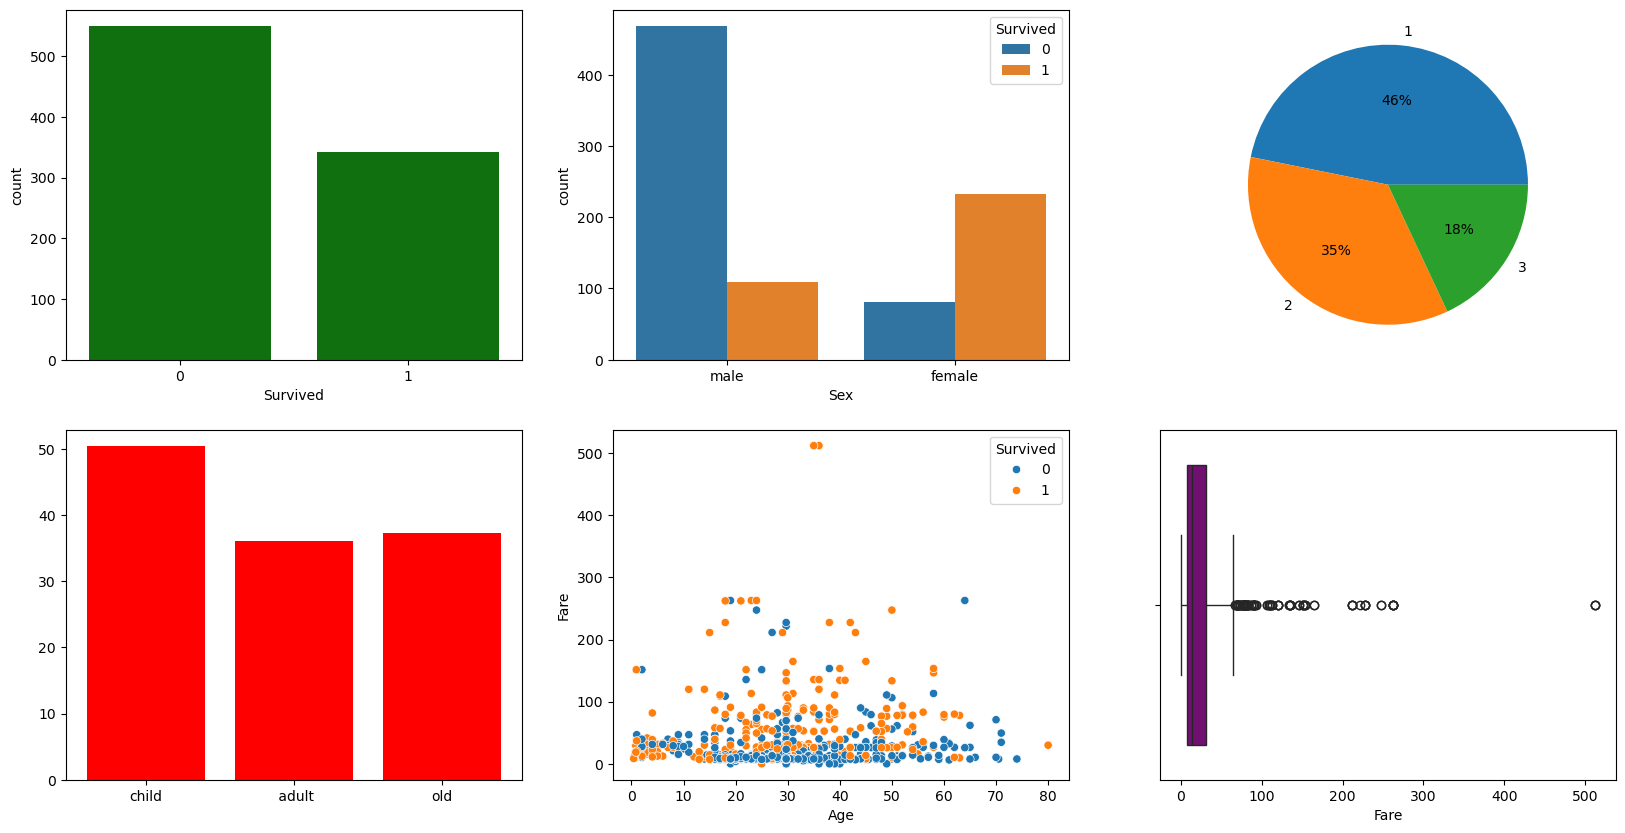

In [31]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x="Survived",color="green",data=df)

plt.subplot(2,3,2)
sns.countplot(x="Sex",hue="Survived",data=df)

plt.subplot(2,3,3)
plt.pie(a.values,labels=a.index,autopct="%1d%%")
plt.subplot(2,3,4)
plt.bar(b.index,b.values,color="red")

plt.subplot(2,3,5)
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)

plt.subplot(2,3,6)
sns.boxplot(x="Fare",color="purple",data=df)
plt.show()


## Data story Telling

In [32]:
###Most of the peoplie died in the incident
###Female are more in the incident
###First class passengers survived more in the incident
###Children survived more,followed by adults
###